# What are the most demanded skills for the top 3 most popular data roles?

## Methodology

1. Clean-up skill column
2. Calculate skill count based on 'job_title_short'
3. Calculate skill percentage
4. Plot final findings

In [1]:
#Libraries import code
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from datasets import load_dataset

#datasets/dataframes to be used
dataset = load_dataset('coachprerakmehta/data_jobs')
df = dataset['train'].to_pandas()

#quick data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if isinstance(skill_list, str) and pd.notna(skill_list) else skill_list)

In [2]:
#Filter by US country
df_US = df[df['job_country'] == 'United States']

In [3]:
#explode job skills
df_skills = df_US.explode('job_skills')

In [4]:
#groupby to group data
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size()

#reset index to change to df and rename values to skill count
df_skills_count = df_skills_count.reset_index(name='skill_count')

#sort descending by skill count
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

In [5]:
#get to three job titles
job_titles = df_skills_count['job_title_short'].unique().tolist()
#get first three job titles of the list
job_titles=job_titles[:3]
#sort alphabetically
sorted(job_titles[:3])



['Data Analyst', 'Data Engineer', 'Data Scientist']

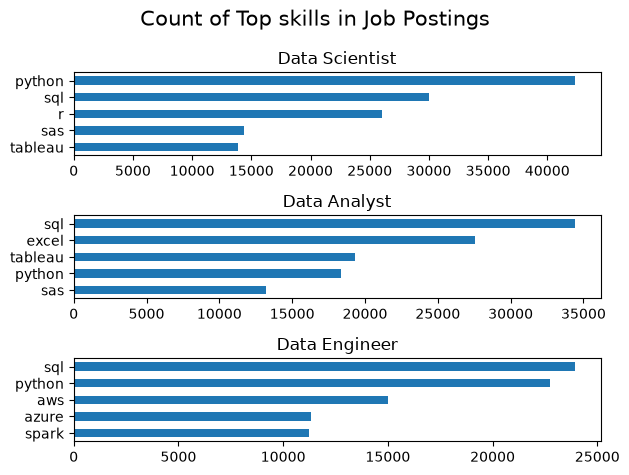

In [6]:
#plot 3 different charts for each job title
fig, ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles): 
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title, legend=False)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')

fig.suptitle('Count of Top skills in Job Postings', fontsize=15)

fig.tight_layout()
plt.show()

In [7]:
#new variable to get count of job title postings
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')
#new variable to get percentage merging count of job title and count of skills df
df_skill_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
#new column for skill percentage
df_skill_perc['skill_perc'] = (df_skill_perc['skill_count'] / df_skill_perc['jobs_total'])*100

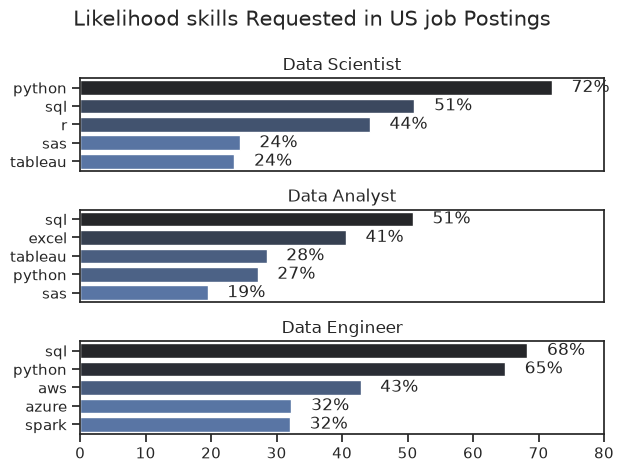

In [8]:
sns.set_theme(style='ticks')

fig, ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles): 
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].sort_values(by='skill_perc', ascending=True).tail(5)
    sns.barplot(data=df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,80)    

    for n, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v+3, n, f'{v:.0f}%', va='center') 

    if i != len(job_titles)-1:
        ax[i].set_xticks([])


fig.suptitle('Likelihood skills Requested in US job Postings', fontsize=15)
fig.tight_layout()
plt.show()